# 06 - Machine Learning

## 1. Giới thiệu

### 1.1. Mục tiêu của Notebook

### 1.2. Vai trò của Machine Learning trong dự án

### 1.3. Kiến trúc pipeline

## 2. Đọc dữ liệu

### 2.1. Đọc dữ liệu từ PostgreSQL

In [52]:
import json
import os
import re
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from sqlalchemy import URL, create_engine, text

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda value: f'{value:,.5f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5.5)
plt.rcParams['font.size'] = 10


def find_project_root(start: Path) -> Path:
    # Notebook có thể được mở từ project root hoặc notebooks_v1/.
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'notebooks_v1').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và notebooks_v1/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
REPORT_IMAGES_DIR = PROJECT_ROOT / 'reports' / 'images'
for directory in (MODELS_DIR, REPORT_IMAGES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

METADATA_PATH = PROCESSED_DIR / 'feature_metadata.json'
if not METADATA_PATH.is_file():
    raise FileNotFoundError(
        f'Không tìm thấy {METADATA_PATH}. Hãy chạy hoàn chỉnh Notebook 05 trước.'
    )

feature_metadata = json.loads(METADATA_PATH.read_text(encoding='utf-8'))
TARGET_COLUMN = feature_metadata['target']
FEATURE_NAMES = list(feature_metadata['feature_names'])
FEATURE_TABLE = feature_metadata.get('postgres_table', 'public.city_temperature_features')

# Xác nhận metadata do Notebook 05 bàn giao có đủ thông tin cốt lõi cho huấn luyện.
# country_name không là feature trong phiên bản pipeline hiện tại, nên Notebook 06
# không yêu cầu One-Hot Encoding cho cột này.
required_metadata = {'target', 'feature_names', 'postgres_table', 'split_counts'}
missing_metadata = sorted(required_metadata - set(feature_metadata))
if missing_metadata:
    raise RuntimeError(
        'feature_metadata.json thiếu trường bắt buộc: ' + ', '.join(missing_metadata)
    )
if not FEATURE_NAMES:
    raise RuntimeError('feature_metadata.json không có feature nào để huấn luyện.')

# -----------------------------------------------------------------------
# Cấu hình tài nguyên. USE_FULL_DATA=True chỉ phù hợp máy có RAM/CPU lớn.
# Chế độ mặc định lấy mẫu ngẫu nhiên ổn định ngay trong PostgreSQL.
# -----------------------------------------------------------------------
RANDOM_SEED = 42
USE_FULL_DATA = False
MAX_ROWS_BY_SPLIT = {
    'train': 750_000,
    'validation': 200_000,
    'test': 200_000,
}
RF_MAX_TRAIN_ROWS = 300_000
XGB_MAX_TRAIN_ROWS = 500_000
FINAL_MAX_TRAIN_ROWS = 600_000
DIAGNOSTIC_PLOT_ROWS = 5_000
N_JOBS = -1

ENV_PATH = PROJECT_ROOT / '.env'
if not ENV_PATH.is_file():
    raise FileNotFoundError(f'Không tìm thấy {ENV_PATH}.')
load_dotenv(ENV_PATH, override=False)

required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise ValueError(f'.env thiếu các biến: {missing_env}')

DB_ENGINE = create_engine(
    URL.create(
        drivername='postgresql+psycopg2',
        username=os.environ['DB_USER'],
        password=os.environ['DB_PASSWORD'],
        host=os.environ['DB_HOST'],
        port=int(os.environ['DB_PORT']),
        database=os.environ['DB_NAME'],
    ),
    pool_pre_ping=True,
    connect_args={'connect_timeout': 10},
)


def quote_identifier(identifier: str) -> str:
    # Metadata do dự án tạo nhưng vẫn kiểm tra để tránh sinh SQL không hợp lệ.
    if not re.fullmatch(r'[A-Za-z_][A-Za-z0-9_]*', identifier):
        raise ValueError(f'Tên SQL không hợp lệ: {identifier!r}')
    return f'"{identifier}"'


schema_name, table_name = FEATURE_TABLE.split('.', maxsplit=1)
qualified_table = f'{quote_identifier(schema_name)}.{quote_identifier(table_name)}'

with DB_ENGINE.connect() as connection:
    table_check = pd.read_sql_query(
        text(
            'SELECT current_database() AS database_name, '
            f"to_regclass('{schema_name}.{table_name}') IS NOT NULL AS table_exists"
        ),
        connection,
    )
display(table_check)
if not bool(table_check.loc[0, 'table_exists']):
    raise RuntimeError(f'Không tìm thấy bảng {FEATURE_TABLE}. Hãy chạy Notebook 05.')

# Chỉ đọc các cột cần modeling và một số khóa để kiểm tra/hiển thị dự đoán.
REFERENCE_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
    'data_split',
]
SELECT_COLUMNS = list(dict.fromkeys(REFERENCE_COLUMNS + [TARGET_COLUMN] + FEATURE_NAMES))

with DB_ENGINE.connect() as connection:
    db_columns = pd.read_sql_query(
        text(
            "SELECT column_name FROM information_schema.columns "
            "WHERE table_schema = :schema AND table_name = :table"
        ),
        connection,
        params={'schema': schema_name, 'table': table_name},
    )['column_name'].tolist()

missing_columns = set(SELECT_COLUMNS) - set(db_columns)
if missing_columns:
    raise RuntimeError(
        'Bảng PostgreSQL không khớp metadata; thiếu cột: '
        f'{sorted(missing_columns)}. Hãy chạy lại Notebook 05.'
    )

with DB_ENGINE.connect() as connection:
    database_split_counts = pd.read_sql_query(
        text(
            f'SELECT data_split, COUNT(*)::BIGINT AS row_count '
            f'FROM {qualified_table} GROUP BY data_split ORDER BY data_split'
        ),
        connection,
    )
display(database_split_counts)


def load_split(split_name: str, max_rows: int | None) -> pd.DataFrame:
    # BERNOULLI lấy mẫu ở mức dòng, REPEATABLE giúp kết quả có thể tái lập.
    allowed_splits = {'train', 'validation', 'test'}
    if split_name not in allowed_splits:
        raise ValueError(f'Split không hợp lệ: {split_name}')

    total_rows = int(
        database_split_counts.loc[
            database_split_counts['data_split'].eq(split_name), 'row_count'
        ].iloc[0]
    )
    column_sql = ', '.join(quote_identifier(name) for name in SELECT_COLUMNS)

    if USE_FULL_DATA or max_rows is None or max_rows >= total_rows:
        query = (
            f'SELECT {column_sql} FROM {qualified_table} '
            'WHERE data_split = :split_name'
        )
    else:
        # Nhân 1.35 để xác suất lấy đủ LIMIT cao hơn dù BERNOULLI có dao động.
        sample_percent = min(100.0, max(0.01, max_rows / total_rows * 135.0))
        query = (
            f'SELECT {column_sql} FROM {qualified_table} '
            f'TABLESAMPLE BERNOULLI ({sample_percent:.8f}) REPEATABLE ({RANDOM_SEED}) '
            'WHERE data_split = :split_name '
            f'LIMIT {int(max_rows)}'
        )

    start = time.perf_counter()
    with DB_ENGINE.connect() as connection:
        frame = pd.read_sql_query(
            text(query),
            connection,
            params={'split_name': split_name},
            parse_dates=['observation_date'],
        )
    print(
        f'{split_name:10s}: nạp {len(frame):,}/{total_rows:,} dòng '
        f'trong {time.perf_counter() - start:,.1f} giây'
    )
    return frame


split_frames = [
    load_split(split_name, None if USE_FULL_DATA else MAX_ROWS_BY_SPLIT[split_name])
    for split_name in ('train', 'validation', 'test')
]
model_df = pd.concat(split_frames, ignore_index=True)
del split_frames

# Hạ kiểu sau khi đọc để giảm bộ nhớ; tên chỉ dùng tham chiếu nên lưu category.
for column in FEATURE_NAMES + [TARGET_COLUMN, 'latitude', 'longitude']:
    if column in model_df.columns:
        model_df[column] = pd.to_numeric(model_df[column], errors='coerce').astype('float32')
for column in ('city_name', 'country_name', 'data_split'):
    model_df[column] = model_df[column].astype('category')

print(f'Nguồn dữ liệu : {FEATURE_TABLE}')
print(f'Số feature    : {len(FEATURE_NAMES)}')
print(f'Chế độ        : {"FULL DATA" if USE_FULL_DATA else "RESOURCE-AWARE SAMPLE"}')
print(f'Bộ nhớ        : {model_df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB')

,database_name,table_exists
0,climate_db,True


,data_split,row_count
0,test,736478
1,train,4468327
2,validation,374280


train     : nạp 750,000/4,468,327 dòng trong 8.2 giây
validation: nạp 200,000/374,280 dòng trong 4.7 giây
test      : nạp 200,000/736,478 dòng trong 4.1 giây
Nguồn dữ liệu : public.city_temperature_features
Số feature    : 19
Chế độ        : RESOURCE-AWARE SAMPLE
Bộ nhớ        : 100.9 MB


### 2.2. Kiểm tra kích thước dữ liệu

In [53]:
shape_summary = pd.DataFrame(
    {
        'Số dòng đã nạp': model_df.groupby('data_split', observed=True).size(),
        'Số dòng trong PostgreSQL': database_split_counts.set_index('data_split')['row_count'],
    }
).fillna(0).astype('int64')
shape_summary['Tỷ lệ đã nạp (%)'] = (
    shape_summary['Số dòng đã nạp'] / shape_summary['Số dòng trong PostgreSQL'] * 100
)

display(shape_summary)
print(f'Kích thước DataFrame modeling: {model_df.shape[0]:,} dòng × {model_df.shape[1]} cột')
print(f'Feature từ metadata          : {len(FEATURE_NAMES)}')

if model_df.empty:
    raise RuntimeError('Không đọc được dữ liệu modeling từ PostgreSQL.')
if set(model_df['data_split'].astype(str).unique()) != {'train', 'validation', 'test'}:
    raise RuntimeError('Dữ liệu đã nạp không đủ ba split train/validation/test.')

,Số dòng đã nạp,Số dòng trong PostgreSQL,Tỷ lệ đã nạp (%)
data_split,,,
test,200000,736478,27.15628
train,750000,4468327,16.78481
validation,200000,374280,53.43593


Kích thước DataFrame modeling: 1,150,000 dòng × 24 cột
Feature từ metadata          : 19


### 2.3. Kiểm tra kiểu dữ liệu

In [54]:
from io import StringIO

info_buffer = StringIO()
model_df.info(
    buf=info_buffer,
    verbose=True,
    max_cols=len(model_df.columns) + 1,
    show_counts=True,
    memory_usage='deep',
)
print(info_buffer.getvalue())

dtype_summary = (
    model_df.dtypes.astype(str).value_counts().rename_axis('Dtype').to_frame('Số cột')
)
display(dtype_summary)

feature_dtype_check = pd.DataFrame(
    {
        'dtype': model_df[FEATURE_NAMES].dtypes.astype(str),
        'is_numeric': [
            pd.api.types.is_numeric_dtype(model_df[name]) for name in FEATURE_NAMES
        ],
    }
)
display(feature_dtype_check)

if not feature_dtype_check['is_numeric'].all():
    invalid = feature_dtype_check.index[~feature_dtype_check['is_numeric']].tolist()
    raise RuntimeError(f'Feature chưa được chuyển sang kiểu số: {invalid}')

<class 'pandas.DataFrame'>
RangeIndex: 1150000 entries, 0 to 1149999
Data columns (total 24 columns):
 #   Column                    Non-Null Count    Dtype        
---  ------                    --------------    -----        
 0   observation_date          1150000 non-null  datetime64[s]
 1   city_name                 1150000 non-null  category     
 2   country_name              1150000 non-null  category     
 3   latitude                  1150000 non-null  float32      
 4   longitude                 1150000 non-null  float32      
 5   data_split                1150000 non-null  category     
 6   city_average_temperature  1150000 non-null  float32      
 7   month_sin                 1150000 non-null  float32      
 8   month_cos                 1150000 non-null  float32      
 9   climatic_month_sin        1150000 non-null  float32      
 10  climatic_month_cos        1150000 non-null  float32      
 11  years_since_start         1150000 non-null  float32      
 12  abs_latitud

,Số cột
Dtype,
float32,20
category,3
datetime64[s],1


,dtype,is_numeric
month_sin,float32,True
month_cos,float32,True
climatic_month_sin,float32,True
climatic_month_cos,float32,True
years_since_start,float32,True
latitude,float32,True
abs_latitude,float32,True
hemisphere_north,float32,True
longitude,float32,True
abslat_x_month_sin,float32,True


### 2.4. Xác định Feature và Target

In [55]:
TARGET = TARGET_COLUMN
MODEL_FEATURES_FROM_METADATA = list(FEATURE_NAMES)

if TARGET in MODEL_FEATURES_FROM_METADATA:
    raise RuntimeError('Target đang nằm trong danh sách feature — data leakage trực tiếp.')
if len(MODEL_FEATURES_FROM_METADATA) != len(set(MODEL_FEATURES_FROM_METADATA)):
    raise RuntimeError('Danh sách feature trong metadata có tên trùng.')

feature_target_contract = pd.DataFrame(
    {
        'Vai trò': ['Target', 'Feature', 'Khóa tham chiếu', 'Nhãn chia dữ liệu'],
        'Cột': [
            TARGET,
            f'{len(MODEL_FEATURES_FROM_METADATA)} cột trong feature_names',
            ', '.join(REFERENCE_COLUMNS[:-1]),
            'data_split',
        ],
        'Đưa vào X': ['Không', 'Có', 'Không', 'Không'],
    }
)
display(feature_target_contract)
print('Target:', TARGET)
print('Năm feature đầu:', MODEL_FEATURES_FROM_METADATA[:5])
print('Năm feature cuối:', MODEL_FEATURES_FROM_METADATA[-5:])

,Vai trò,Cột,Đưa vào X
0,Target,city_average_temperature,Không
1,Feature,19 cột trong feature_names,Có
2,Khóa tham chiếu,"observation_date, city_name, country_name, lat...",Không
3,Nhãn chia dữ liệu,data_split,Không


Target: city_average_temperature
Năm feature đầu: ['month_sin', 'month_cos', 'climatic_month_sin', 'climatic_month_cos', 'years_since_start']
Năm feature cuối: ['temp_roll_mean_12', 'temp_anomaly_lag_12', 'land_temperature_lag_1', 'land_anomaly_lag_1', 'city_uncertainty_lag_1']


## 3. Chuẩn bị dữ liệu

### 3.1. Phát hiện các cột có vấn đề

In [56]:
feature_frame = model_df[MODEL_FEATURES_FROM_METADATA]

problem_rows = []
for name in MODEL_FEATURES_FROM_METADATA:
    series = feature_frame[name]
    numeric_values = series.to_numpy(dtype='float64', na_value=np.nan)
    problem_rows.append(
        {
            'Feature': name,
            'Dtype': str(series.dtype),
            'Thiếu': int(series.isna().sum()),
            'Thiếu (%)': float(series.isna().mean() * 100),
            'Vô cực': int(np.isinf(numeric_values).sum()),
            'Số giá trị khác nhau': int(series.nunique(dropna=True)),
            'Cột hằng số': bool(series.nunique(dropna=True) <= 1),
        }
    )

problem_table = pd.DataFrame(problem_rows).set_index('Feature')
display(problem_table)

print('Feature có missing:')
display(problem_table[problem_table['Thiếu'] > 0].sort_values('Thiếu (%)', ascending=False))
print('Feature hằng số hoặc toàn NaN:')
display(problem_table[problem_table['Cột hằng số']])

raw_string_columns = [
    name for name in ('city_name', 'country_name') if name in MODEL_FEATURES_FROM_METADATA
]
if raw_string_columns:
    raise RuntimeError(f'Chuỗi gốc không được phép nằm trong feature_names: {raw_string_columns}')

,Dtype,Thiếu,Thiếu (%),Vô cực,Số giá trị khác nhau,Cột hằng số
Feature,,,,,,
month_sin,float32,0,0.00000,0,7,False
month_cos,float32,0,0.00000,0,7,False
climatic_month_sin,float32,0,0.00000,0,7,False
climatic_month_cos,float32,0,0.00000,0,7,False
years_since_start,float32,0,0.00000,0,151,False
latitude,float32,0,0.00000,0,72,False
abs_latitude,float32,0,0.00000,0,43,False
hemisphere_north,float32,0,0.00000,0,2,False
longitude,float32,0,0.00000,0,1053,False


Feature có missing:


,Dtype,Thiếu,Thiếu (%),Vô cực,Số giá trị khác nhau,Cột hằng số
Feature,,,,,,
temp_anomaly_lag_12,float32,6941,0.60357,0,81079,False
temp_roll_mean_12,float32,3384,0.29426,0,255282,False
temp_lag_1,float32,816,0.07096,0,54942,False
city_uncertainty_lag_1,float32,816,0.07096,0,3889,False
land_temperature_lag_1,float32,400,0.03478,0,1676,False
land_anomaly_lag_1,float32,400,0.03478,0,1610,False


Feature hằng số hoặc toàn NaN:


,Dtype,Thiếu,Thiếu (%),Vô cực,Số giá trị khác nhau,Cột hằng số
Feature,,,,,,


### 3.2. Xử lý các cột có vấn đề 

In [57]:
# Giá trị vô cực không có ý nghĩa với ba mô hình; chuyển thành NaN để pipeline impute.
model_df[MODEL_FEATURES_FROM_METADATA] = model_df[
    MODEL_FEATURES_FROM_METADATA
].replace([np.inf, -np.inf], np.nan)

# Chỉ loại cột hằng số trên tập train đã nạp. Không lựa chọn theo test/importance tại đây.
train_mask_for_schema = model_df['data_split'].astype(str).eq('train')
train_unique_counts = model_df.loc[
    train_mask_for_schema, MODEL_FEATURES_FROM_METADATA
].nunique(dropna=True)
CONSTANT_FEATURES = train_unique_counts[train_unique_counts <= 1].index.tolist()
MODEL_FEATURES = [
    name for name in MODEL_FEATURES_FROM_METADATA if name not in CONSTANT_FEATURES
]

if not MODEL_FEATURES:
    raise RuntimeError('Không còn feature sau kiểm tra cột hằng số.')

print(f'Feature metadata : {len(MODEL_FEATURES_FROM_METADATA)}')
print(f'Cột hằng số loại : {len(CONSTANT_FEATURES)} — {CONSTANT_FEATURES or "không có"}')
print(f'Feature modeling : {len(MODEL_FEATURES)}')
print('Missing chưa được điền toàn cục; mỗi pipeline sẽ fit imputer chỉ trên train.')

Feature metadata : 19
Cột hằng số loại : 0 — không có
Feature modeling : 19
Missing chưa được điền toàn cục; mỗi pipeline sẽ fit imputer chỉ trên train.


### 3.3. Chia tập Train/Test theo theo thời gian (Time-based Split)

In [58]:
train_df = model_df.loc[model_df['data_split'].astype(str).eq('train')].copy()
validation_df = model_df.loc[model_df['data_split'].astype(str).eq('validation')].copy()
test_df = model_df.loc[model_df['data_split'].astype(str).eq('test')].copy()

X_train = train_df[MODEL_FEATURES]
y_train = train_df[TARGET].astype('float32')
X_validation = validation_df[MODEL_FEATURES]
y_validation = validation_df[TARGET].astype('float32')
X_test = test_df[MODEL_FEATURES]
y_test = test_df[TARGET].astype('float32')

if y_train.isna().any() or y_validation.isna().any() or y_test.isna().any():
    raise RuntimeError('Target còn missing sau Feature Engineering.')

split_check = pd.DataFrame(
    {
        'Rows': [len(X_train), len(X_validation), len(X_test)],
        'Min date': [
            train_df['observation_date'].min(),
            validation_df['observation_date'].min(),
            test_df['observation_date'].min(),
        ],
        'Max date': [
            train_df['observation_date'].max(),
            validation_df['observation_date'].max(),
            test_df['observation_date'].max(),
        ],
        'Target mean': [y_train.mean(), y_validation.mean(), y_test.mean()],
    },
    index=['train', 'validation', 'test'],
)
display(split_check)

if not (
    train_df['observation_date'].max() < validation_df['observation_date'].min()
    and validation_df['observation_date'].max() < test_df['observation_date'].min()
):
    raise RuntimeError('Các split thời gian bị chồng lấn hoặc sai thứ tự.')

MODEL_RESULTS = {}
MODEL_TIMINGS = {}
MODEL_OBJECTS = {}
MODEL_FEATURE_MAP = {}
TEST_PREDICTIONS = {}


def regression_metrics(y_true, y_pred) -> dict:
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': float(r2_score(y_true, y_pred)),
    }


def take_training_sample(X, y, max_rows: int | None):
    if max_rows is None or len(X) <= max_rows:
        return X, y
    positions = np.random.default_rng(RANDOM_SEED).choice(
        len(X), size=max_rows, replace=False
    )
    positions.sort()
    return X.iloc[positions], y.iloc[positions]


def plot_regression_diagnostics(y_true, y_pred, model_name: str, split_name: str):
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    if len(y_true_array) > DIAGNOSTIC_PLOT_ROWS:
        positions = np.random.default_rng(RANDOM_SEED).choice(
            len(y_true_array), size=DIAGNOSTIC_PLOT_ROWS, replace=False
        )
        y_true_array = y_true_array[positions]
        y_pred_array = y_pred_array[positions]

    residuals = y_true_array - y_pred_array
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].scatter(y_true_array, y_pred_array, s=9, alpha=0.25)
    lower = min(y_true_array.min(), y_pred_array.min())
    upper = max(y_true_array.max(), y_pred_array.max())
    axes[0].plot([lower, upper], [lower, upper], '--', color='red', linewidth=1.5)
    axes[0].set_xlabel('Actual (°C)')
    axes[0].set_ylabel('Predicted (°C)')
    axes[0].set_title(f'{model_name} — Actual vs Predicted ({split_name})')

    axes[1].scatter(y_pred_array, residuals, s=9, alpha=0.25)
    axes[1].axhline(0, linestyle='--', color='red', linewidth=1.5)
    axes[1].set_xlabel('Predicted (°C)')
    axes[1].set_ylabel('Residual = Actual − Predicted (°C)')
    axes[1].set_title(f'{model_name} — Residual ({split_name})')

    plt.tight_layout()
    safe_name = re.sub(r'[^a-z0-9]+', '_', model_name.lower()).strip('_')
    output_path = REPORT_IMAGES_DIR / f'{safe_name}_{split_name}_diagnostics.png'
    plt.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Đã lưu:', output_path)


def save_model_artifact(path: Path, model_name: str, estimator, features: list[str]):
    artifact = {
        'model_name': model_name,
        'model': estimator,
        'features': list(features),
        'target': TARGET,
        'forecast_scenario': feature_metadata.get('forecast_scenario'),
        'country_encoding': feature_metadata.get('country_encoding'),
        'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
        'source_table': FEATURE_TABLE,
    }
    joblib.dump(artifact, path)
    print(f'Đã lưu {path.name}: {path.stat().st_size / 1024**2:,.2f} MB')


print('PASS: train < validation < test theo thời gian; không dùng random split.')

,Rows,Min date,Max date,Target mean
train,750000,1863-01-01,1983-12-01,17.20410
validation,200000,1984-01-01,1993-12-01,18.00493
test,200000,1994-01-01,2013-09-01,18.37752


PASS: train < validation < test theo thời gian; không dùng random split.


## 4. Mô hình Linear Regression

### 4.1. Giới thiệu Linear Regression

### 4.2. Lựa chọn Feature đầu vào cho Linear Regression

In [59]:
# Linear Regression dùng toàn bộ feature hợp lệ. StandardScaler giúp hệ số
# giữa các feature có thang đo khác nhau trở nên so sánh được.
LINEAR_FEATURES = list(MODEL_FEATURES)
print(f'Linear Regression sử dụng {len(LINEAR_FEATURES)} feature.')
display(pd.Series(LINEAR_FEATURES, name='Feature').to_frame().head(20))

Linear Regression sử dụng 19 feature.


,Feature
0,month_sin
1,month_cos
2,climatic_month_sin
3,climatic_month_cos
4,years_since_start
5,latitude
6,abs_latitude
7,hemisphere_north
8,longitude
9,abslat_x_month_sin


### 4.3. Huấn luyện mô hình Linear Regression

In [60]:
linear_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression(n_jobs=N_JOBS)),
    ]
)

linear_start = time.perf_counter()
linear_pipeline.fit(X_train[LINEAR_FEATURES], y_train)
linear_train_seconds = time.perf_counter() - linear_start

MODEL_OBJECTS['Linear Regression'] = linear_pipeline
MODEL_FEATURE_MAP['Linear Regression'] = LINEAR_FEATURES
MODEL_TIMINGS['Linear Regression'] = {'Train seconds': linear_train_seconds}

print(f'Đã huấn luyện Linear Regression trong {linear_train_seconds:,.1f} giây.')

Đã huấn luyện Linear Regression trong 1.7 giây.


### 4.4. Đánh giá mô hình Linear Regression

,MAE,RMSE,R2
Linear Regression,0.84817,1.24884,0.98441


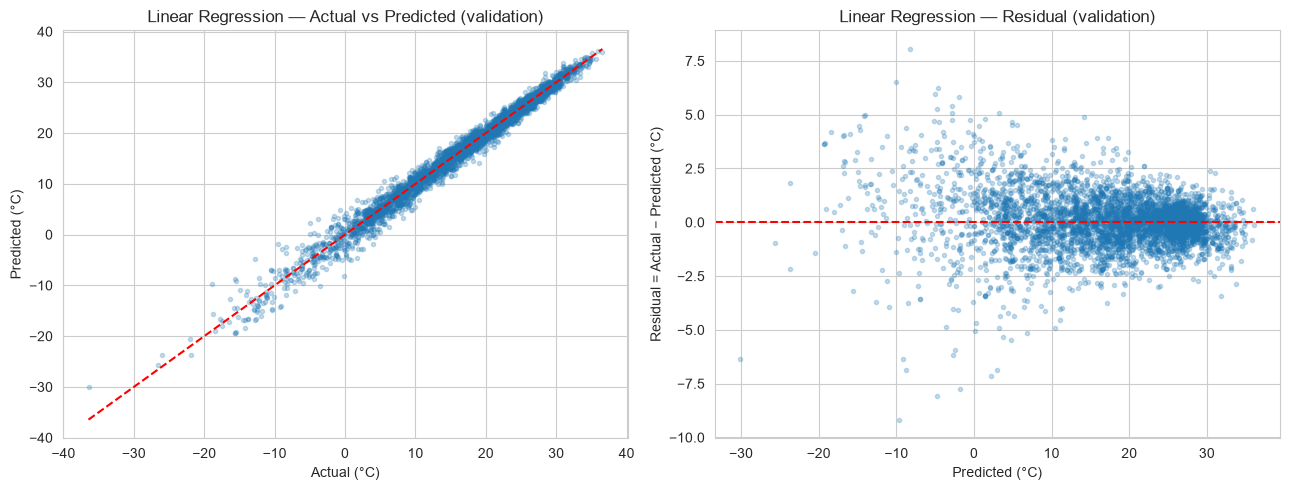

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\linear_regression_validation_diagnostics.png
Hệ số có độ lớn cao nhất sau chuẩn hóa:


,Coefficient,|Coefficient|
loc_month_climatology,9.30897,9.30897
temp_lag_1,1.01913,1.01913
land_temperature_lag_1,-0.88374,0.88374
month_sin,-0.76619,0.76619
month_cos,-0.39019,0.39019
abslat_x_month_cos,-0.22406,0.22406
abslat_x_month_sin,0.22307,0.22307
land_anomaly_lag_1,0.20280,0.20280
years_since_start,0.15097,0.15097
climatic_month_cos,0.05372,0.05372


In [61]:
predict_start = time.perf_counter()
linear_validation_pred = linear_pipeline.predict(X_validation[LINEAR_FEATURES])
linear_validation_seconds = time.perf_counter() - predict_start
linear_validation_metrics = regression_metrics(y_validation, linear_validation_pred)

MODEL_RESULTS['Linear Regression'] = {
    'validation': linear_validation_metrics,
}
MODEL_TIMINGS['Linear Regression']['Validation predict seconds'] = linear_validation_seconds

display(pd.DataFrame([linear_validation_metrics], index=['Linear Regression']))
plot_regression_diagnostics(
    y_validation, linear_validation_pred, 'Linear Regression', 'validation'
)

# Vì X đã được chuẩn hóa, |coefficient| có thể dùng để xem mức ảnh hưởng tuyến tính.
linear_model = linear_pipeline.named_steps['model']
transformed_names = linear_pipeline.named_steps['imputer'].get_feature_names_out(
    LINEAR_FEATURES
)
linear_coefficients = (
    pd.Series(linear_model.coef_, index=transformed_names, name='Coefficient')
    .to_frame()
)
linear_coefficients['|Coefficient|'] = linear_coefficients['Coefficient'].abs()
linear_coefficients = linear_coefficients.sort_values('|Coefficient|', ascending=False)
print('Hệ số có độ lớn cao nhất sau chuẩn hóa:')
display(linear_coefficients.head(25))

### 4.5.	Dự đoán trên tập test

,MAE,RMSE,R2
Linear Regression,0.87259,1.26651,0.98407


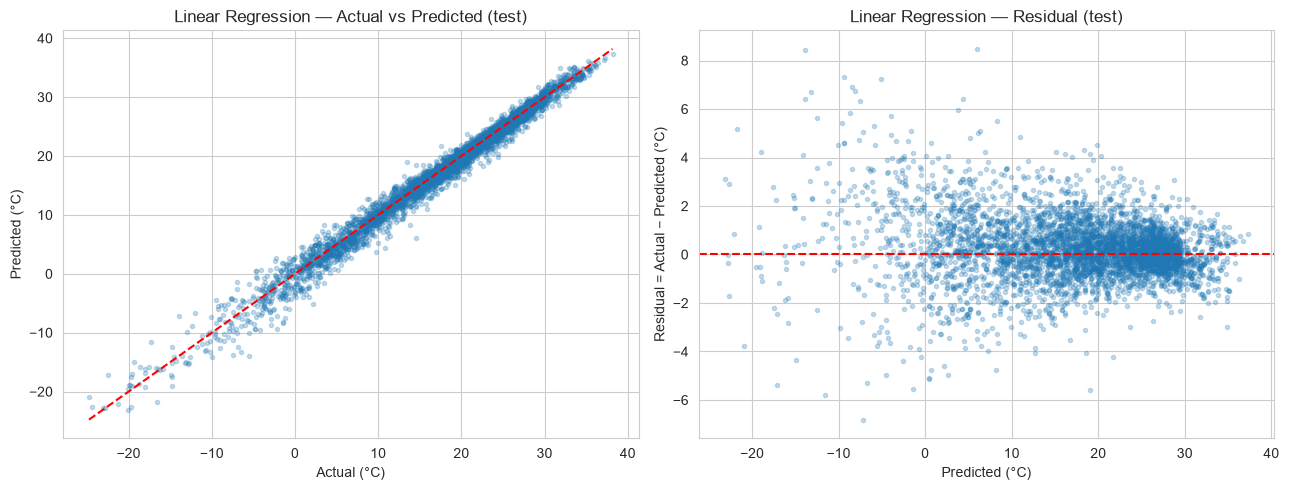

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\linear_regression_test_diagnostics.png


In [62]:
# Cấu hình mô hình đã được khóa trước cell này; không điều chỉnh theo test.
linear_test_pred = linear_pipeline.predict(X_test[LINEAR_FEATURES])
linear_test_metrics = regression_metrics(y_test, linear_test_pred)
MODEL_RESULTS['Linear Regression']['test'] = linear_test_metrics
TEST_PREDICTIONS['Linear Regression'] = linear_test_pred

display(pd.DataFrame([linear_test_metrics], index=['Linear Regression']))
plot_regression_diagnostics(y_test, linear_test_pred, 'Linear Regression', 'test')

### 4.6.	Lưu mô hình Linear Regression

In [63]:
LINEAR_MODEL_PATH = MODELS_DIR / 'linear_regression_model.joblib'
save_model_artifact(
    LINEAR_MODEL_PATH,
    'Linear Regression',
    linear_pipeline,
    LINEAR_FEATURES,
)

Đã lưu linear_regression_model.joblib: 0.00 MB


## 5. Mô hình  Random Forest

### 5.1. Giới thiệu Random Forest

### 5.2. Lựa chọn Feature đầu vào cho Random Forest

In [64]:
# Random Forest không cần scaling nhưng vẫn cần impute NaN.
RF_FEATURES = list(MODEL_FEATURES)
X_train_rf, y_train_rf = take_training_sample(
    X_train[RF_FEATURES], y_train, RF_MAX_TRAIN_ROWS
)
print(f'Random Forest sử dụng {len(RF_FEATURES)} feature.')
print(f'Train sample       : {len(X_train_rf):,}/{len(X_train):,} dòng')

Random Forest sử dụng 19 feature.
Train sample       : 300,000/750,000 dòng


### 5.3. Huấn luyện mô hình Random Forest

In [65]:
rf_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('model', RandomForestRegressor(
            n_estimators=120,
            max_depth=20,
            min_samples_leaf=5,
            max_features=0.75,
            bootstrap=True,
            max_samples=0.80,
            n_jobs=N_JOBS,
            random_state=RANDOM_SEED,
            verbose=0,
        )),
    ]
)

rf_start = time.perf_counter()
rf_pipeline.fit(X_train_rf, y_train_rf)
rf_train_seconds = time.perf_counter() - rf_start

MODEL_OBJECTS['Random Forest'] = rf_pipeline
MODEL_FEATURE_MAP['Random Forest'] = RF_FEATURES
MODEL_TIMINGS['Random Forest'] = {'Train seconds': rf_train_seconds}

print(f'Đã huấn luyện Random Forest trong {rf_train_seconds / 60:,.1f} phút.')

Đã huấn luyện Random Forest trong 0.3 phút.


### 5.4. Đánh giá mô hình Random Forest

,MAE,RMSE,R2
Random Forest,0.85881,1.26585,0.98398


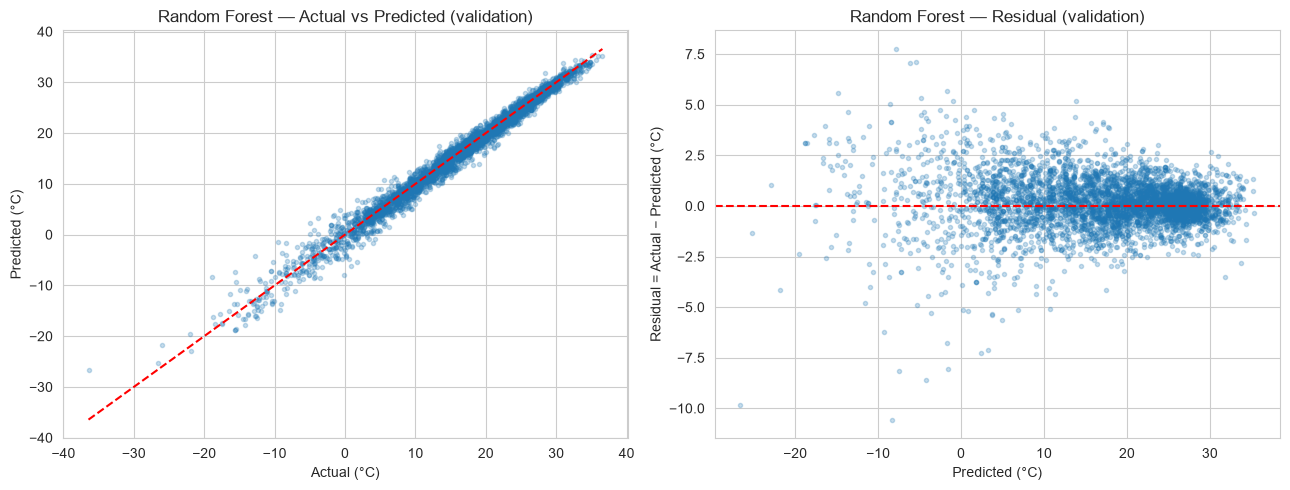

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\random_forest_validation_diagnostics.png


In [66]:
predict_start = time.perf_counter()
rf_validation_pred = rf_pipeline.predict(X_validation[RF_FEATURES])
rf_validation_seconds = time.perf_counter() - predict_start
rf_validation_metrics = regression_metrics(y_validation, rf_validation_pred)

MODEL_RESULTS['Random Forest'] = {'validation': rf_validation_metrics}
MODEL_TIMINGS['Random Forest']['Validation predict seconds'] = rf_validation_seconds

display(pd.DataFrame([rf_validation_metrics], index=['Random Forest']))
plot_regression_diagnostics(y_validation, rf_validation_pred, 'Random Forest', 'validation')

### 5.5. Xem Feature Importance của Random Forest

,Importance
loc_month_climatology,0.78671
temp_lag_1,0.14595
temp_roll_mean_12,0.03391
abs_latitude,0.01402
abslat_x_month_cos,0.00675
loc_temperature_std,0.00595
years_since_start,0.00106
land_anomaly_lag_1,0.00090
land_temperature_lag_1,0.00089
temp_anomaly_lag_12,0.00080


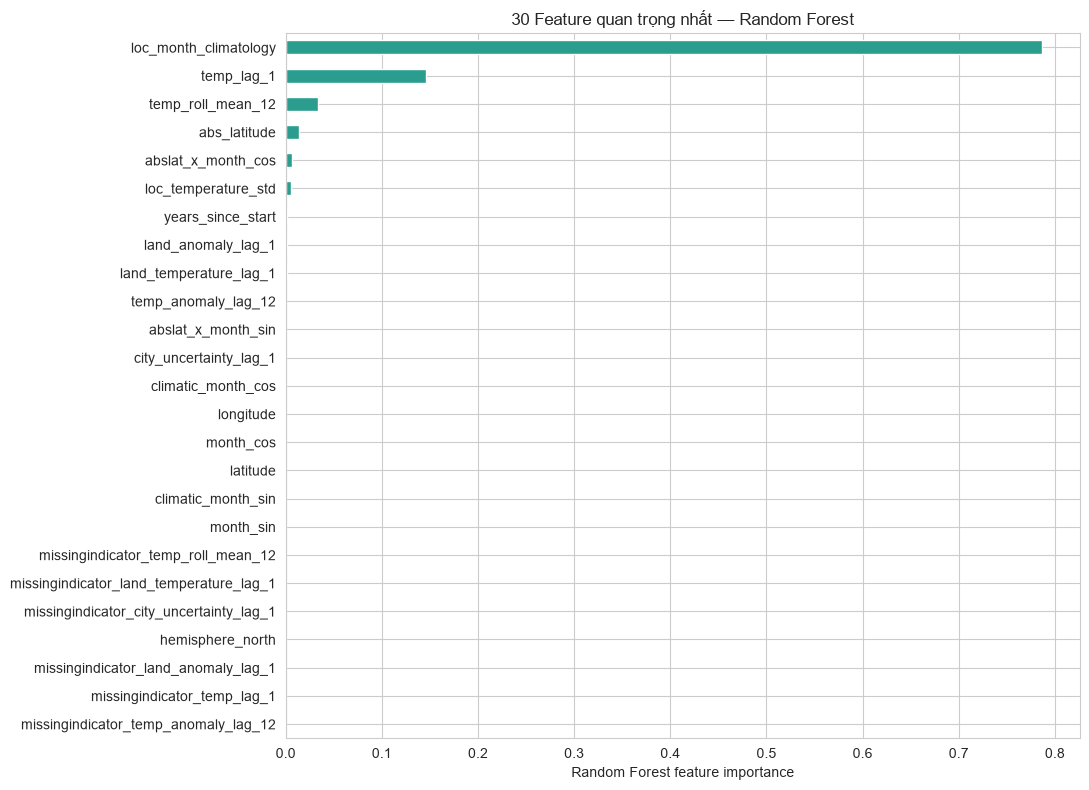

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\random_forest_feature_importance.png


In [67]:
rf_model = rf_pipeline.named_steps['model']
rf_transformed_names = rf_pipeline.named_steps['imputer'].get_feature_names_out(RF_FEATURES)
rf_feature_importance = (
    pd.Series(
        rf_model.feature_importances_,
        index=rf_transformed_names,
        name='Importance',
    )
    .sort_values(ascending=False)
)
display(rf_feature_importance.head(30).to_frame())

top_rf_importance = rf_feature_importance.head(30).sort_values()
ax = top_rf_importance.plot.barh(figsize=(11, 8), color='#2a9d8f')
ax.set_xlabel('Random Forest feature importance')
ax.set_title('30 Feature quan trọng nhất — Random Forest')
plt.tight_layout()
rf_importance_path = REPORT_IMAGES_DIR / 'random_forest_feature_importance.png'
plt.savefig(rf_importance_path, dpi=180, bbox_inches='tight')
plt.show()
print('Đã lưu:', rf_importance_path)

### 5.6. Dự đoán trên tập test

,MAE,RMSE,R2
Random Forest,0.95094,1.34961,0.98191


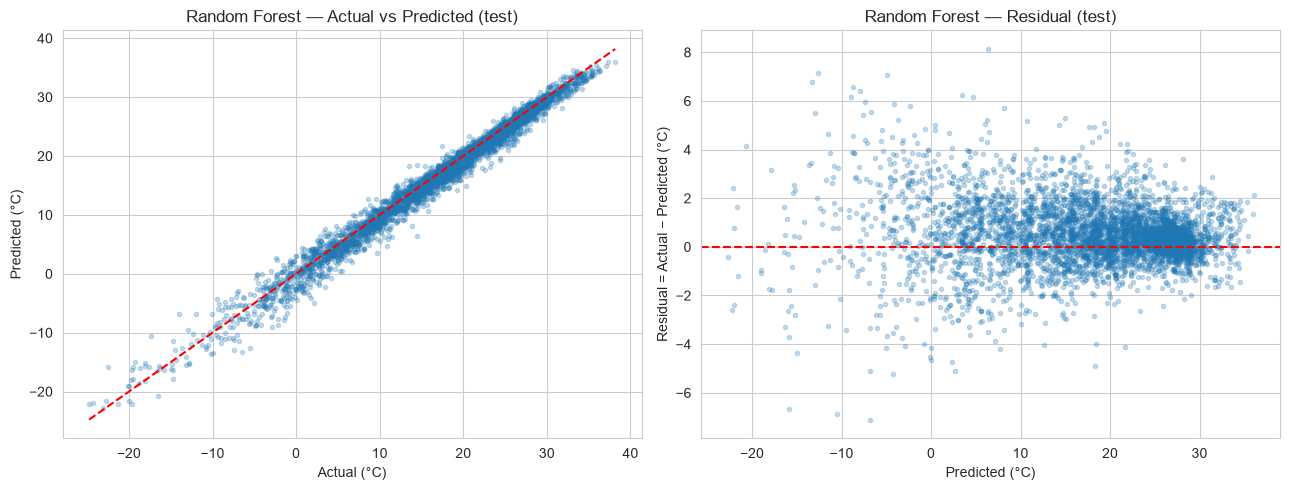

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\random_forest_test_diagnostics.png


In [68]:
rf_test_pred = rf_pipeline.predict(X_test[RF_FEATURES])
rf_test_metrics = regression_metrics(y_test, rf_test_pred)
MODEL_RESULTS['Random Forest']['test'] = rf_test_metrics
TEST_PREDICTIONS['Random Forest'] = rf_test_pred

display(pd.DataFrame([rf_test_metrics], index=['Random Forest']))
plot_regression_diagnostics(y_test, rf_test_pred, 'Random Forest', 'test')

### 5.7. Dự đoán với giá trị đầu vào cụ thể

In [69]:
rf_example_position = 0
rf_example_features = X_test.iloc[[rf_example_position]][RF_FEATURES]
rf_example_prediction = float(rf_pipeline.predict(rf_example_features)[0])
rf_example_actual = float(y_test.iloc[rf_example_position])

rf_example = test_df.iloc[[rf_example_position]][
    ['observation_date', 'city_name', 'country_name', 'latitude', 'longitude']
].copy()
rf_example['Actual temperature (°C)'] = rf_example_actual
rf_example['Predicted temperature (°C)'] = rf_example_prediction
rf_example['Absolute error (°C)'] = abs(rf_example_actual - rf_example_prediction)
display(rf_example)

,observation_date,city_name,country_name,latitude,longitude,Actual temperature (°C),Predicted temperature (°C),Absolute error (°C)
950000,1994-04-01,Velikiy Novgorod,Russia,58.66000,30.77000,6.80900,4.41133,2.39767


### 5.8. Lưu mô hình Random Forest

In [70]:
RF_MODEL_PATH = MODELS_DIR / 'random_forest_model.joblib'
save_model_artifact(
    RF_MODEL_PATH,
    'Random Forest',
    rf_pipeline,
    RF_FEATURES,
)

Đã lưu random_forest_model.joblib: 335.07 MB


## 6. Mô hình XGBoost

### 6.1. Giới thiệu XGBoost

### 6.2. Lựa chọn Feature đầu vào cho XGBoost  

In [71]:
XGB_FEATURES = list(MODEL_FEATURES)
X_train_xgb, y_train_xgb = take_training_sample(
    X_train[XGB_FEATURES], y_train, XGB_MAX_TRAIN_ROWS
)
print(f'XGBoost sử dụng {len(XGB_FEATURES)} feature.')
print(f'Train sample   : {len(X_train_xgb):,}/{len(X_train):,} dòng')

XGBoost sử dụng 19 feature.
Train sample   : 500,000/750,000 dòng


### 6.3. Huấn luyện mô hình XGBoost

In [72]:
try:
    from xgboost import XGBRegressor
except ImportError as error:
    raise ImportError(
        'Notebook 06 yêu cầu XGBoost. Cài trong đúng môi trường kernel bằng: '
        'python -m pip install "xgboost>=2.0"'
    ) from error

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    tree_method='hist',
    eval_metric='rmse',
    early_stopping_rounds=50,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

xgb_start = time.perf_counter()
xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_validation[XGB_FEATURES], y_validation)],
    verbose=False,
)
xgb_train_seconds = time.perf_counter() - xgb_start

MODEL_OBJECTS['XGBoost'] = xgb_model
MODEL_FEATURE_MAP['XGBoost'] = XGB_FEATURES
MODEL_TIMINGS['XGBoost'] = {'Train seconds': xgb_train_seconds}

print(f'Đã huấn luyện XGBoost trong {xgb_train_seconds / 60:,.1f} phút.')
print('Best iteration:', getattr(xgb_model, 'best_iteration', None))

Đã huấn luyện XGBoost trong 0.1 phút.
Best iteration: 113


### 6.4. Đánh giá mô hình XGBoost

,MAE,RMSE,R2
XGBoost,0.84499,1.25566,0.98424


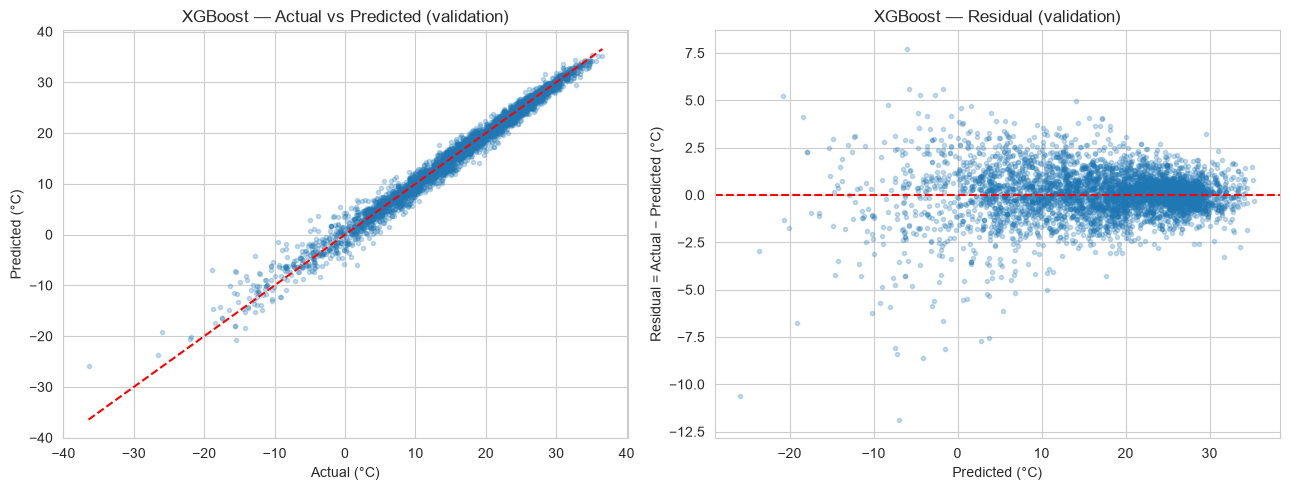

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\xgboost_validation_diagnostics.png


In [73]:
predict_start = time.perf_counter()
xgb_validation_pred = xgb_model.predict(X_validation[XGB_FEATURES])
xgb_validation_seconds = time.perf_counter() - predict_start
xgb_validation_metrics = regression_metrics(y_validation, xgb_validation_pred)

MODEL_RESULTS['XGBoost'] = {'validation': xgb_validation_metrics}
MODEL_TIMINGS['XGBoost']['Validation predict seconds'] = xgb_validation_seconds

display(pd.DataFrame([xgb_validation_metrics], index=['XGBoost']))
plot_regression_diagnostics(y_validation, xgb_validation_pred, 'XGBoost', 'validation')

### 6.5. Xem Feature Importance của XGBoost

,Importance
loc_month_climatology,0.79425
temp_lag_1,0.12193
abslat_x_month_cos,0.02812
climatic_month_sin,0.02031
temp_roll_mean_12,0.01312
loc_temperature_std,0.00497
month_cos,0.00432
month_sin,0.00375
abslat_x_month_sin,0.00240
latitude,0.00181


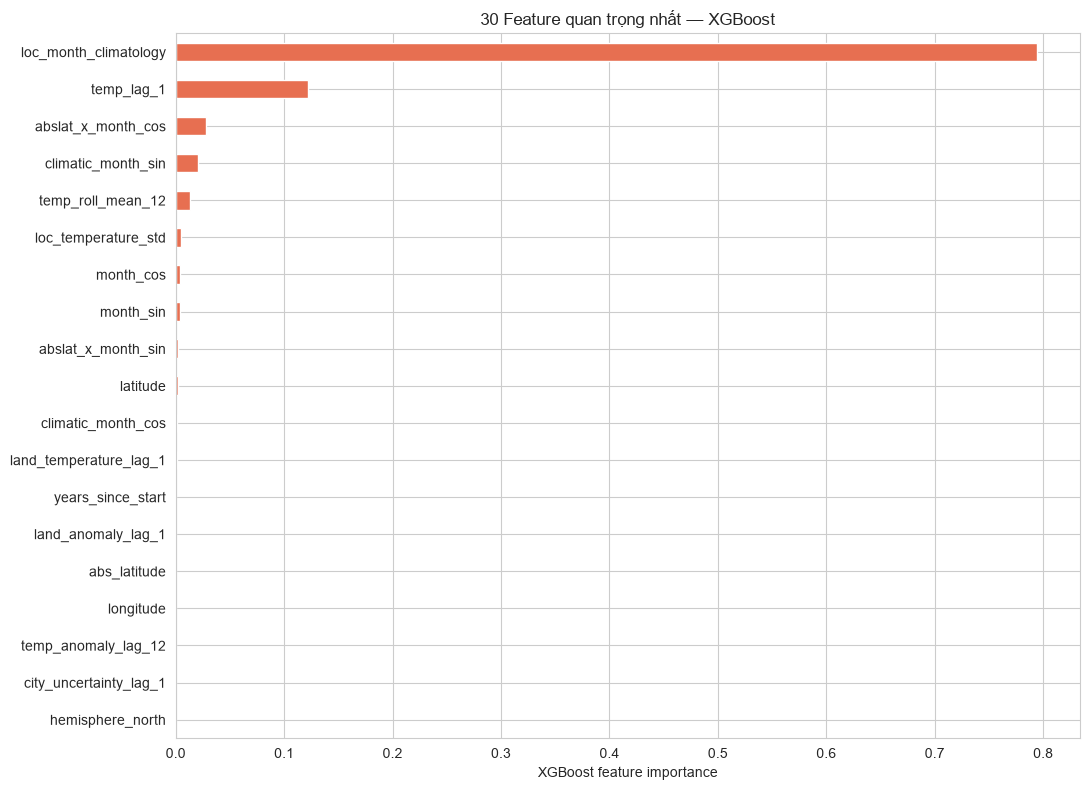

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\xgboost_feature_importance.png


In [74]:
xgb_feature_importance = (
    pd.Series(xgb_model.feature_importances_, index=XGB_FEATURES, name='Importance')
    .sort_values(ascending=False)
)
display(xgb_feature_importance.head(30).to_frame())

top_xgb_importance = xgb_feature_importance.head(30).sort_values()
ax = top_xgb_importance.plot.barh(figsize=(11, 8), color='#e76f51')
ax.set_xlabel('XGBoost feature importance')
ax.set_title('30 Feature quan trọng nhất — XGBoost')
plt.tight_layout()
xgb_importance_path = REPORT_IMAGES_DIR / 'xgboost_feature_importance.png'
plt.savefig(xgb_importance_path, dpi=180, bbox_inches='tight')
plt.show()
print('Đã lưu:', xgb_importance_path)

### 6.6. Dự đoán trên tập test

,MAE,RMSE,R2
XGBoost,0.92083,1.31352,0.98287


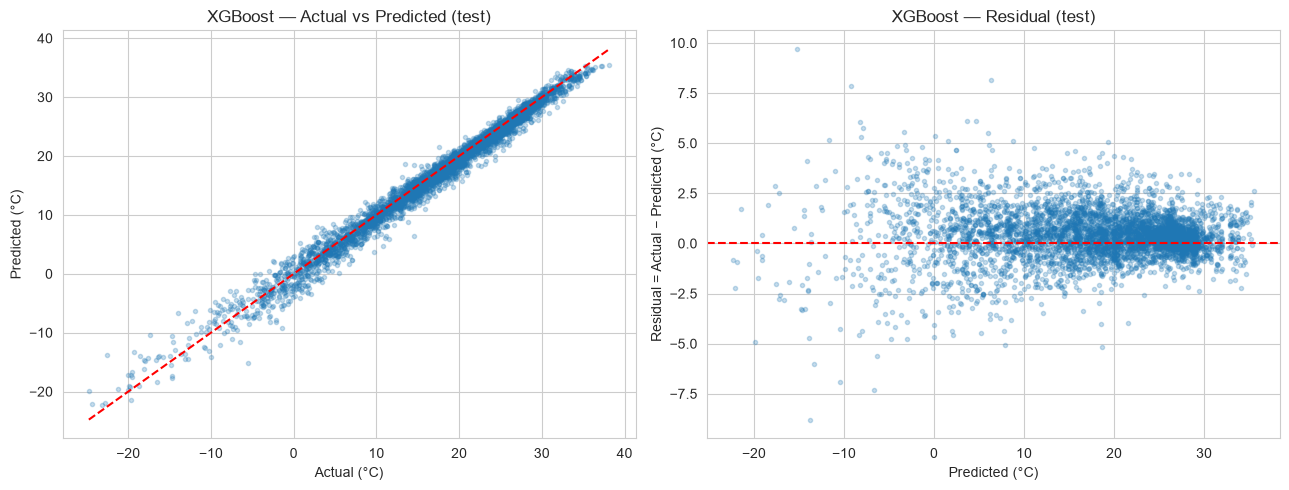

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\xgboost_test_diagnostics.png


In [75]:
xgb_test_pred = xgb_model.predict(X_test[XGB_FEATURES])
xgb_test_metrics = regression_metrics(y_test, xgb_test_pred)
MODEL_RESULTS['XGBoost']['test'] = xgb_test_metrics
TEST_PREDICTIONS['XGBoost'] = xgb_test_pred

display(pd.DataFrame([xgb_test_metrics], index=['XGBoost']))
plot_regression_diagnostics(y_test, xgb_test_pred, 'XGBoost', 'test')

### 6.7. Dự đoán với giá trị đầu vào cụ thể

In [76]:
xgb_example_position = 0
xgb_example_features = X_test.iloc[[xgb_example_position]][XGB_FEATURES]
xgb_example_prediction = float(xgb_model.predict(xgb_example_features)[0])
xgb_example_actual = float(y_test.iloc[xgb_example_position])

xgb_example = test_df.iloc[[xgb_example_position]][
    ['observation_date', 'city_name', 'country_name', 'latitude', 'longitude']
].copy()
xgb_example['Actual temperature (°C)'] = xgb_example_actual
xgb_example['Predicted temperature (°C)'] = xgb_example_prediction
xgb_example['Absolute error (°C)'] = abs(xgb_example_actual - xgb_example_prediction)
display(xgb_example)

,observation_date,city_name,country_name,latitude,longitude,Actual temperature (°C),Predicted temperature (°C),Absolute error (°C)
950000,1994-04-01,Velikiy Novgorod,Russia,58.66000,30.77000,6.80900,4.36892,2.44008


### 6.8. Lưu mô hình XGBoost

In [77]:
XGB_MODEL_PATH = MODELS_DIR / 'xgboost_model.joblib'
save_model_artifact(
    XGB_MODEL_PATH,
    'XGBoost',
    xgb_model,
    XGB_FEATURES,
)

Đã lưu xgboost_model.joblib: 2.49 MB


## 7. So sánh các mô hình

Tạo bảng tổng hợp

,Train seconds,Validation predict seconds,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
Model,,,,,,,,
Linear Regression,1.68126,0.04271,0.84817,1.24884,0.98441,0.87259,1.26651,0.98407
XGBoost,4.44416,0.06746,0.84499,1.25566,0.98424,0.92083,1.31352,0.98287
Random Forest,19.85124,0.41769,0.85881,1.26585,0.98398,0.95094,1.34961,0.98191


Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed\model_comparison.csv


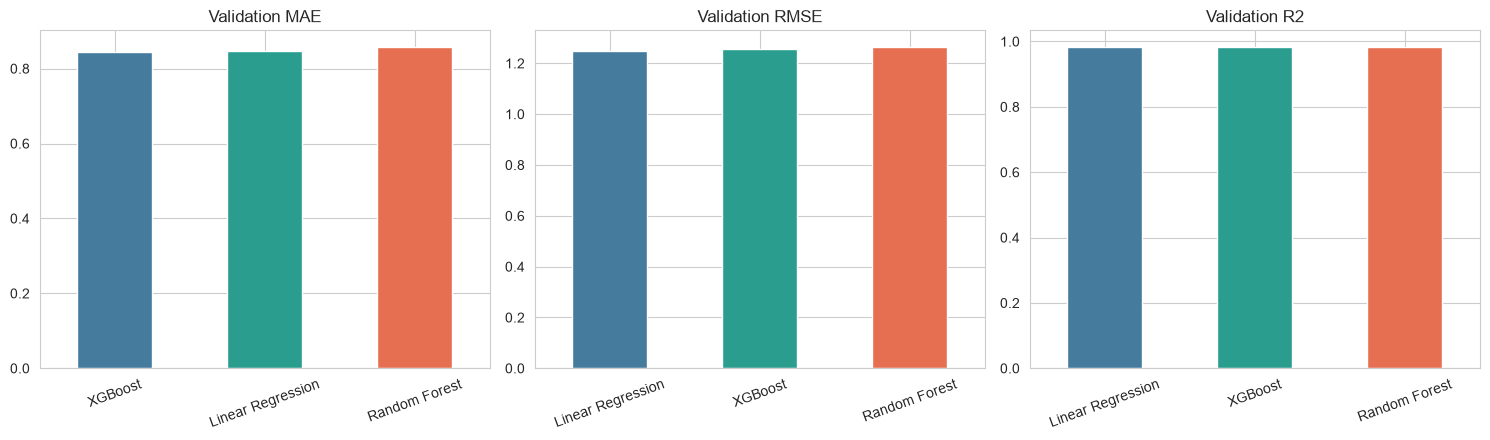

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\model_comparison_validation.png


In [78]:
comparison_rows = []
for model_name, split_metrics in MODEL_RESULTS.items():
    row = {
        'Model': model_name,
        'Train seconds': MODEL_TIMINGS[model_name]['Train seconds'],
        'Validation predict seconds': MODEL_TIMINGS[model_name][
            'Validation predict seconds'
        ],
    }
    for split_name in ('validation', 'test'):
        for metric_name, metric_value in split_metrics[split_name].items():
            row[f'{split_name.title()} {metric_name}'] = metric_value
    comparison_rows.append(row)

model_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index('Model')
    .sort_values('Validation RMSE')
)
display(model_comparison)

COMPARISON_PATH = PROCESSED_DIR / 'model_comparison.csv'
model_comparison.to_csv(COMPARISON_PATH, encoding='utf-8', float_format='%.6f')
print('Đã lưu:', COMPARISON_PATH)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for axis, metric in zip(axes, ('MAE', 'RMSE', 'R2')):
    values = model_comparison[f'Validation {metric}'].sort_values(
        ascending=(metric != 'R2')
    )
    values.plot.bar(ax=axis, color=['#457b9d', '#2a9d8f', '#e76f51'][:len(values)])
    axis.set_title(f'Validation {metric}')
    axis.set_xlabel('')
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()
comparison_plot_path = REPORT_IMAGES_DIR / 'model_comparison_validation.png'
plt.savefig(comparison_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Đã lưu:', comparison_plot_path)

## 8. Lựa chọn mô hình cuối cùng

Mô hình được chọn theo Validation RMSE: Linear Regression
Validation RMSE                  : 1.24884 °C


,Validation MAE,Validation RMSE,Validation R2,Train seconds,Validation predict seconds
Model,,,,,
Linear Regression,0.84817,1.24884,0.98441,1.68126,0.04271
XGBoost,0.84499,1.25566,0.98424,4.44416,0.06746
Random Forest,0.85881,1.26585,0.98398,19.85124,0.41769


,MAE,RMSE,R2
Final Linear Regression,0.86691,1.25865,0.98427


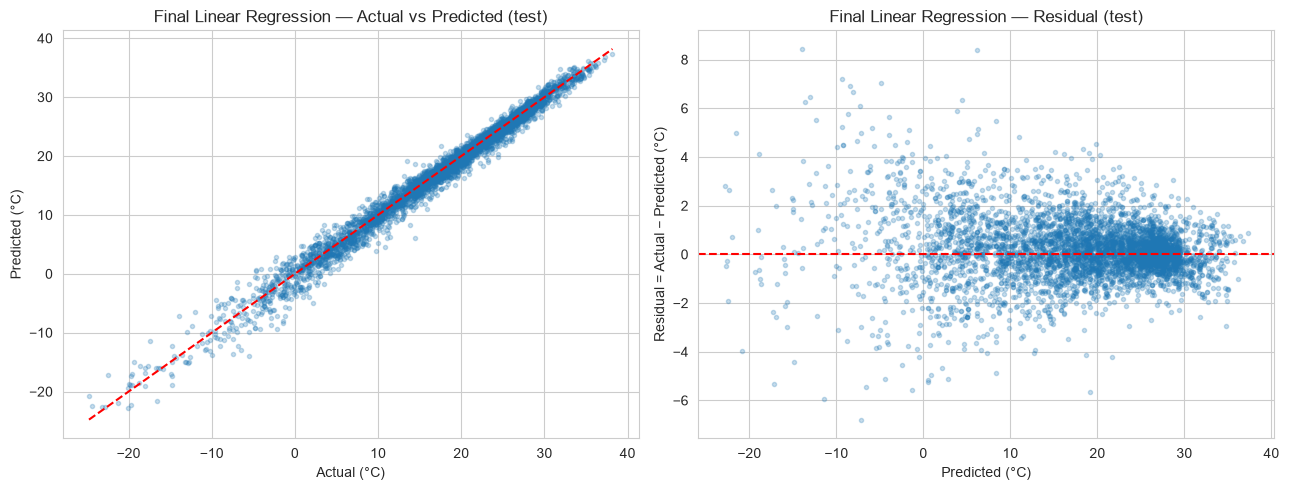

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images\final_linear_regression_test_diagnostics.png
Final model: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\models\final_model.joblib (0.00 MB)
Metadata   : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\models\final_model_metadata.json


In [79]:
# Quyết định chỉ dùng Validation RMSE. Test không tham gia chọn mô hình.
BEST_MODEL_NAME = model_comparison['Validation RMSE'].idxmin()
best_validation_rmse = float(model_comparison.loc[BEST_MODEL_NAME, 'Validation RMSE'])

print(f'Mô hình được chọn theo Validation RMSE: {BEST_MODEL_NAME}')
print(f'Validation RMSE                  : {best_validation_rmse:.5f} °C')
display(
    model_comparison[
        ['Validation MAE', 'Validation RMSE', 'Validation R2',
         'Train seconds', 'Validation predict seconds']
    ]
)

best_features = MODEL_FEATURE_MAP[BEST_MODEL_NAME]
best_estimator = MODEL_OBJECTS[BEST_MODEL_NAME]

# Refit mô hình cuối trên train + validation sau khi đã khóa lựa chọn.
X_development = pd.concat(
    [X_train[best_features], X_validation[best_features]],
    ignore_index=True,
)
y_development = pd.concat([y_train, y_validation], ignore_index=True)
X_final_train, y_final_train = take_training_sample(
    X_development, y_development, FINAL_MAX_TRAIN_ROWS
)

final_model = clone(best_estimator)
if BEST_MODEL_NAME == 'XGBoost':
    # Khi refit train + validation không còn eval_set riêng để early stopping.
    best_iteration = getattr(best_estimator, 'best_iteration', None)
    final_n_estimators = (best_iteration + 1) if best_iteration is not None else 400
    final_model.set_params(
        n_estimators=final_n_estimators,
        early_stopping_rounds=None,
    )

final_fit_start = time.perf_counter()
final_model.fit(X_final_train, y_final_train)
final_fit_seconds = time.perf_counter() - final_fit_start

final_test_prediction = final_model.predict(X_test[best_features])
final_test_metrics = regression_metrics(y_test, final_test_prediction)
display(pd.DataFrame([final_test_metrics], index=[f'Final {BEST_MODEL_NAME}']))
plot_regression_diagnostics(
    y_test, final_test_prediction, f'Final {BEST_MODEL_NAME}', 'test'
)

FINAL_MODEL_PATH = MODELS_DIR / 'final_model.joblib'
final_artifact = {
    'model_name': BEST_MODEL_NAME,
    'model': final_model,
    'features': list(best_features),
    'target': TARGET,
    'validation_metrics_before_refit': MODEL_RESULTS[BEST_MODEL_NAME]['validation'],
    'test_metrics_after_refit': final_test_metrics,
    'fit_rows': int(len(X_final_train)),
    'fit_seconds': float(final_fit_seconds),
    'forecast_scenario': feature_metadata.get('forecast_scenario'),
    'country_encoding': feature_metadata.get('country_encoding'),
    'source_table': FEATURE_TABLE,
    'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
}
joblib.dump(final_artifact, FINAL_MODEL_PATH)

FINAL_METADATA_PATH = MODELS_DIR / 'final_model_metadata.json'
FINAL_METADATA_PATH.write_text(
    json.dumps(
        {key: value for key, value in final_artifact.items() if key != 'model'},
        ensure_ascii=False,
        indent=2,
    ),
    encoding='utf-8',
)

print(f'Final model: {FINAL_MODEL_PATH} ({FINAL_MODEL_PATH.stat().st_size / 1024**2:,.2f} MB)')
print('Metadata   :', FINAL_METADATA_PATH)

## 9. Kết luận

In [80]:
completion_summary = pd.DataFrame(
    {
        'Giá trị': [
            FEATURE_TABLE,
            len(MODEL_FEATURES_FROM_METADATA),
            len(MODEL_FEATURES),
            f'{len(X_train):,} / {len(X_validation):,} / {len(X_test):,}',
            ', '.join(MODEL_RESULTS.keys()),
            BEST_MODEL_NAME,
            final_test_metrics['MAE'],
            final_test_metrics['RMSE'],
            final_test_metrics['R2'],
            str(FINAL_MODEL_PATH),
        ]
    },
    index=[
        'Bảng nguồn',
        'Feature từ Notebook 05',
        'Feature dùng để modeling',
        'Rows train / validation / test',
        'Các mô hình đã huấn luyện',
        'Mô hình cuối',
        'Final Test MAE',
        'Final Test RMSE',
        'Final Test R²',
        'Artifact bàn giao Notebook 07',
    ],
)
display(completion_summary)

required_outputs = [
    LINEAR_MODEL_PATH,
    RF_MODEL_PATH,
    XGB_MODEL_PATH,
    FINAL_MODEL_PATH,
    FINAL_METADATA_PATH,
    COMPARISON_PATH,
]
missing_outputs = [str(path) for path in required_outputs if not path.is_file()]
if missing_outputs:
    raise RuntimeError(f'Thiếu artifact sau khi chạy Notebook 06: {missing_outputs}')

print('PASS: đã train, đánh giá và lưu đủ ba mô hình.')
print('PASS: mô hình cuối được chọn bằng validation, không chọn bằng test.')
print('PASS: final_model.joblib sẵn sàng bàn giao cho Notebook 07.')

,Giá trị
Bảng nguồn,public.city_temperature_features
Feature từ Notebook 05,19
Feature dùng để modeling,19
Rows train / validation / test,"750,000 / 200,000 / 200,000"
Các mô hình đã huấn luyện,"Linear Regression, Random Forest, XGBoost"
Mô hình cuối,Linear Regression
Final Test MAE,0.86691
Final Test RMSE,1.25865
Final Test R²,0.98427
Artifact bàn giao Notebook 07,E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface...


PASS: đã train, đánh giá và lưu đủ ba mô hình.
PASS: mô hình cuối được chọn bằng validation, không chọn bằng test.
PASS: final_model.joblib sẵn sàng bàn giao cho Notebook 07.
